In [1]:
include("/Users/ndiaz/psm-nr_final/PSM-FINAL.jl")
include("/Users/ndiaz/psm-nr_final/SWPSM-FINAL.jl")
#include("./SWPSM2D_functions.jl")
include("/Users/ndiaz/Downloads/SWPSM2D_functions_WORKING_MARCH_01.jl")


using StatsPlots
using Images
using Random
using LaTeXStrings
using BM3DDenoise
using LocalFilters
using CSV 
plot_font = "Computer Modern"
default(
    fontfamily=plot_font,
    linewidth=1, 
    framestyle=:box, 
    label=nothing, 
    grid=true
)

In [2]:
function AIC_denoise_image(Y::AbstractMatrix,
                            X::AbstractMatrix,
                           xe_Estims::AbstractMatrix,
                           xe_EstimsVariance::AbstractMatrix,
                           th::Real,
                           patchSize::Int,
                           σe::Real,
                            q_Th::Real)

    Nx, Ny = size(Y)

    # --- Detect textured pixels ---
    TextutedPix_Ind, OL_Plot = outlierPixels_Var(xe_Estims, xe_EstimsVariance, th)

    # --- Valid patch centers ---
    Valid_Inds = valid_centers(TextutedPix_Ind, patchSize, Nx, Ny)

    #REC = Vector{Any}()
    #Sq_Index = Vector{Vector{Int}}()
    REC = []
    REC_VAR=[]
    Sq_Index = []
    
    t0 = time()

    last_idx = Valid_Inds[end]

    for ref_index in Valid_Inds

        # --- Progress report ---
        progress = round(100 * ref_index / last_idx; digits=2)
        if progress in 0:10:100
            println("\n", progress, "% done...")
        end

        ref_p = TextutedPix_Ind[ref_index]

        # --- Avoid reprocessing ---
        if ref_p ∉ vcat(vcat(Sq_Index...)...)

            rp, ref_patch, ref_patch_GT, ref_patch_Y, ref_patch_Viz,
            closest_patches, closest_patches_ind =
                get_K_NearestPatches(
                    xe_Estims,
                    X,
                    Y,
                    ref_index,
                    TextutedPix_Ind,
                    patchSize,
                    σe,
                    q=q_Th
                )            

            weighted_rec_output = AIC_weighted_reconstruction2(
                ref_patch,
                σe,
                closest_patches
            )

            minAICrec = weighted_rec_output[4]
            minAICrec_VAR = weighted_rec_output[7]
            # minAICrec = AIC_weighted_reconstruction_PPCA(
            #     ref_patch,
            #     σe,
            #     closest_patches)[4]
            
            push!(REC, minAICrec)
            push!(REC_VAR, minAICrec_VAR)
            push!(Sq_Index, square_indices(ref_p, patchSize))
        end
    end

    totalTime = time() - t0

    return REC, Sq_Index, totalTime, REC_VAR
end


AIC_denoise_image (generic function with 1 method)

In [3]:
function denoising_example_V2(path, sigma, bool_NLE, bool_allScans, 
                           NLE_patchSize, SelfSim_patchSize, PASS_1_IC, seed,FullImage,q_Th)

    println("Precompiling functions...")
    dummy_Y = rand(Float64, 16, 16) # Tiny 16x16 image
    dummy_sigma = 0.05
    _ = cPSM2D(dummy_Y, dummy_sigma, "AIC_knownSigma", 4)
    println("Compilation complete.")

    # ... [Keep Directory Creation and Image Loading same as original] ...
    IMG_NAME = split(split(path,'/')[end],'.')[1]
    main_folder_name = "NR_example_"*IMG_NAME*"_"*string(sigma)*"Full_Image"*string(FullImage)
    mainfolderpath = "./" * main_folder_name * "/"
    #mkpath(main_folder_name)
    
    if !isdir(mainfolderpath)
        println("Folder not found... Creating folder")
        mkpath(mainfolderpath)
    else
        println("Folder already exists, proceeding...")
    end
    
    W, X, Y, σe,σeClas, Sm_idx1, Sm_idx2 = getNoisyimage(path, sigma, NLE_patchSize, seed, bool_NLE,FullImage)
    print("\n\nSigma Error: ",(σe-sigma)/sigma)
    SmoothRegion = Y[Sm_idx1:Sm_idx1+NLE_patchSize-1, Sm_idx2:Sm_idx2+NLE_patchSize-1]

    # ... [Keep Variance Threshold and First Pass SW-PSM same as original] ...
    SWPSM_smoothRegion = cPSM2D(SmoothRegion, σe, "BIC_knownSigma", 4)
    Xe_SmoothRegion,VAR_SmoothRegion = aggregateScans(SmoothRegion, SWPSM_smoothRegion[1], SWPSM_smoothRegion[2], 4, σe)
    Var_Th = quantile(vcat(VAR_SmoothRegion...),.5)

    ############################################
    #           COMPUTING SWPSM-2D
    ############################################
    PSM_XE_path = joinpath(mainfolderpath, "SWPSM2D_XE.csv")
    PSM_STD_XE_path = joinpath(mainfolderpath, "SWPSM2D_STD_XE.csv")
    PSM_time_path = joinpath(mainfolderpath, "runtime_PSM.csv")
    AIC_NR_aggregate =[[],[]]
    AIC_NR_aggregate = Vector{Any}(undef, 2)
    
    if isfile(PSM_XE_path)
        println("SPSM-V estimate already in folder. Skipping SPSM-V estimation...")
        # Read the file and specify the comma delimiter
        AIC_NR_aggregate[1] = readdlm(PSM_XE_path, ',', Float64)
        AIC_NR_aggregate[2] = readdlm(PSM_STD_XE_path, ',', Float64)
        
        raw_time = readdlm(PSM_time_path, ',')
        time_AIC = raw_time[1] isa Number ? Float64(raw_time[1]) : parse(Float64, raw_time[1])

    else
        spike_TH = bool_allScans ? 14 : 4
        tAIC = time()
        NR_SWPSM_AIC = cPSM2D(Y, σe, "AIC_knownSigma", spike_TH)
        time_AIC = time() - tAIC
        AIC_NR_aggregate = aggregateScans(Y, NR_SWPSM_AIC[1], NR_SWPSM_AIC[2], spike_TH, σe)
        
        writedlm(PSM_time_path, round(time_AIC, digits=3), ',')
        writedlm(joinpath(mainfolderpath, "SWPSM2D_XE.csv"), Float64.(AIC_NR_aggregate[1]), ',')
        writedlm(joinpath(mainfolderpath, "SWPSM2D_STD_XE.csv"), Float64.(AIC_NR_aggregate[2]), ',')
    end
    

    ############################################
    #            BM3D
    ############################################
    # BM3D Baseline
    # Define the file path once for consistency
    bm3d_path = joinpath(mainfolderpath, "BM3D_XE.csv")
    BM_time_path = joinpath(mainfolderpath, "runtime_BM.csv")
    
    if isfile(bm3d_path)
        println("BM3D estimate already in folder. Skipping BM3D estimation...")
        # Read the file and specify the comma delimiter
        Xe_BM = readdlm(bm3d_path, ',', Float64, '\n')
        raw_time = readdlm(BM_time_path, ',')
        time_BM = raw_time[1] isa Number ? Float64(raw_time[1]) : parse(Float64, raw_time[1])
    else
        println("Running BM3D estimation...")
        tBM = time()
        Xe_BM = bm3d(Y, σe)
        time_BM = time() - tBM
        writedlm(BM_time_path, round(time_BM, digits=3), ',')
        writedlm(bm3d_path, Xe_BM, ',')
    end
    ############################################
    #            RR Regression
    ############################################
    
    tSelf = time()
    REC, Sq_Index, _, REC_VAR = AIC_denoise_image(Y, X, AIC_NR_aggregate[1], AIC_NR_aggregate[2], 
                                                  Var_Th, SelfSim_patchSize, σe,q_Th)
    time_SelfSim = time() - tSelf

    Nx, Ny = size(Y)
    flatten_SqInd = vcat(vcat(Sq_Index...)...)
    flatten_REC   = vcat(vcat(REC...)...)
    flatten_REC_VAR = vcat(vcat(REC_VAR...)...)

    # Prepare Grids for Aggregation
    Var_grid_AIC = [ [AIC_NR_aggregate[2][i,j]] for i in 1:Nx, j in 1:Ny]
    empty_grid_AIC = [ [AIC_NR_aggregate[1][i,j]] for i in 1:Nx, j in 1:Ny]
    for i in 1:length(flatten_SqInd)
        append!(Var_grid_AIC[flatten_SqInd[i]], flatten_REC_VAR[i])
        append!(empty_grid_AIC[flatten_SqInd[i]], flatten_REC[i])
    end

    #######################################################
    # Compute Both Combination Methods
    #######################################################
    agg_IVW_Conditional, _ = combine_grids(empty_grid_AIC, Var_grid_AIC,Y, "ivw_conditional")
    agg_IVW_PCA_only, _ = combine_grids(empty_grid_AIC, Var_grid_AIC,Y, "ivw_skip_first")
    agg_IVW_ALL, _ = combine_grids(empty_grid_AIC, Var_grid_AIC,Y, "ivw")

    writedlm(joinpath(mainfolderpath, "XE_HYBRID_PCA.csv"), agg_IVW_PCA_only, ',')
    writedlm(joinpath(mainfolderpath, "XE_HYBRID_PCA+SWPSM.csv"), agg_IVW_ALL, ',')
    writedlm(joinpath(mainfolderpath, "X_EXPERIMENT.csv"), X, ',')
    writedlm(joinpath(mainfolderpath, "Y_EXPERIMENT+SWPSM.csv"), Y, ',')

    #######################################################
    # Metrics
    #######################################################
    # Aggregation Method 1: IVW-ALL
    psnr_ivw = assess_psnr(X, agg_IVW_ALL)
    ssim_ivw = assess_ssim(X, agg_IVW_ALL)

    # Aggregation Method 2: IVW-CONDITIONAL
    psnr_ivw_Conditional = assess_psnr(X, agg_IVW_Conditional)
    ssim_ivw_Conditional = assess_ssim(X, agg_IVW_Conditional)

    # Aggregation Method 3: IVW-PCA ONLY
    psnr_ivw_PCA = assess_psnr(X, agg_IVW_PCA_only)
    ssim_ivw_PCA = assess_ssim(X, agg_IVW_PCA_only)

    # Baselines
    psnr_aic = assess_psnr(X, AIC_NR_aggregate[1])
    psnr_bm3d = assess_psnr(X, Xe_BM)

    ssim_aic = assess_ssim(X, AIC_NR_aggregate[1])
    ssim_bm3d = assess_ssim(X, Xe_BM)

    #######################################################
    # Legacy Results Table (.txt) - Added MinVar
    #######################################################
    pSNRs = [
        ["Method","NL","NLE","seed","pSNR","SSIM","Time_sec"],
        ["SW-PSM AIC", sigma, σe, seed, psnr_aic, ssim_aic, time_AIC],
        ["BM3D", sigma, σe, seed, psnr_bm3d, ssim_bm3d, time_BM],
        ##DIFFERENT AGGREGATIONS (AIC)
        ["Hybrid AIC (IVW) ", sigma, σe, seed, psnr_ivw, ssim_ivw, time_SelfSim+time_AIC],
        ["Hybrid AIC (IVW_Conditional)", sigma, σe, seed, psnr_ivw_Conditional, ssim_ivw_Conditional, time_SelfSim+time_AIC],
        ["Hybrid AIC (PCA_ONLY)", sigma, σe, seed, psnr_ivw_PCA, ssim_ivw_PCA, time_SelfSim+time_AIC],
        ##DIFFERENT AGGREGATIONS (BIC)
    ]
    writedlm(mainfolderpath * "EvaluationMetrics.txt", pSNRs)

    #######################################################
    # Comparison Plot: IVW vs Min-Var
    #######################################################
    p_comp = plot(
        image_plot(agg_IVW_ALL, 0, 1, "Method: IVW_ALL PSNR: $(round(psnr_ivw, digits=2)) dB"),
        image_plot(agg_IVW_Conditional, 0, 1, "Method: IVW-Conditional PSNR: $(round(psnr_ivw_Conditional, digits=2)) dB"),
        image_plot(agg_IVW_PCA_only, 0, 1, "Method: IVW-PCA_ONLY PSNR: $(round(psnr_ivw_PCA, digits=2)) dB"),
        layout=(1, 3), dpi=300, size=(1500, 500)
    )
    savefig(mainfolderpath * "Combination_Comparison.png")

    #######################################################
    # Save Experiment Log (.csv)
    #######################################################
    log_df = DataFrame(
        Seed = seed,
        Nose_Level = sigma, 
        NLE =σe,
        L_NLE = NLE_patchSize, 
        L_SS = SelfSim_patchSize, 
        Random_Seed = seed,
        Var_Th = Var_Th,
        High_Var_Prop = sum(AIC_NR_aggregate[2] .> Var_Th)/(Nx*Ny)
    )
    CSV.write(mainfolderpath * "experiment_log.csv", log_df)

    # Save specific estimates
    # writedlm(mainfolderpath * "SWPSM+minAIC_PCA/Hybrid_IVW_Estim", agg_IVW)
    # writedlm(mainfolderpath * "SWPSM+minAIC_PCA/Hybrid_MinVar_Estim", agg_MinVar)

    #######################################################
    # Plotting
    #######################################################
    mainfolderpath = "./" * main_folder_name * "/"
    default(titlefontsize = 10)
    
    # Residuals and Estimates Plot
    estREd=[]
    if sigma>0
        estREd=plot(
            image_plot(Y,0,1,"Y"),
            image_plot(AIC_NR_aggregate[1],0,1,string("SWPSM \n(PSNR: ", round(psnr_aic, digits=2), " dB)")),
            image_plot(agg_IVW_PCA_only,0,1,string("HYBRID (Aggregation: PCA) \n(PSNR: ", round(psnr_ivw_PCA, digits=2), " dB)")),
            image_plot(agg_IVW_ALL,0,1,string("HYBRID (Aggregation: PCA & SWPSM) \n(PSNR: ", round(psnr_ivw, digits=2), " dB)")),
            image_plot(Xe_BM,0,1,string("BM3D \n(PSNR: ", round(psnr_bm3d, digits=2), " dB)")),
            image_plot(W,-2*sigma,2*sigma,""),
            image_plot(Y-AIC_NR_aggregate[1],-2*sigma,2*sigma,""),
            image_plot(Y-agg_IVW_PCA_only,-2*sigma,2*sigma,""),
            image_plot(Y-agg_IVW_ALL,-2*sigma,2*sigma,""),
            image_plot(Y-Xe_BM,-2*sigma,2*sigma,""),
            layout=(2,5), dpi=300, size = (1600,800)
            )
    else
        estREd=plot(
            image_plot(Y,0,1,"Y"),
            image_plot(AIC_NR_aggregate[1],0,1,string("SWPSM \n(PSNR: ", round(psnr_aic, digits=2), " dB)")),
            image_plot(agg_IVW_PCA_only,0,1,string("HYBRID (Aggregation: PCA) \n(PSNR: ", round(psnr_ivw_PCA, digits=2), " dB)")),
            image_plot(agg_IVW_ALL,0,1,string("HYBRID (Aggregation: PCA & SWPSM) \n(PSNR: ", round(psnr_ivw, digits=2), " dB)")),
            image_plot(W,-2*σe,2*σe,""),
            image_plot(Y-AIC_NR_aggregate[1],-2*σe,2*σe,""),
            image_plot(Y-agg_IVW_PCA_only,-2*σe,2*σe,""),
            image_plot(Y-agg_IVW_ALL,-2*σe,2*σe,""),
            layout=(2,4), dpi=300, size = (1600,800)
            )
    end
    savefig(mainfolderpath * "estimates_and_residuals.png")
    #print(Var_Th)
    # Texture Segmentation Plot
    
    plot(
            image_plot(Y,0,1,"Y"),
            image_plot(AIC_NR_aggregate[1],0,1,string("SWPSM \n(PSNR: ", round(psnr_aic, digits=2), " dB)")),
            image_plot(agg_IVW_ALL,0,1,string("HYBRID (Aggregation: PCA & SWPSM) \n(PSNR: ", round(psnr_ivw, digits=2), " dB)")),
            layout=(1,3), dpi=300, size = (1600,800)
            )
    savefig(mainfolderpath * "ESTIMATE_PLOT.png")
    
    plot(
        image_plot(X,0,1,"Ground Truth"),
        image_plot(AIC_NR_aggregate[2] .> Var_Th, 0, 1, "Texture Mask"),
        layout=(1,2),
        dpi=300, size=(1000,500)
    )
    savefig(mainfolderpath * "Texture_Segmentation.png")

        # Texture Segmentation Plot
    
    plot(
        image_plot(SmoothRegion,0,1,L"S"),
        histogram(vcat(AIC_NR_aggregate[2]...)),
        layout=(1,2),
        dpi=300, size=(500,500)
    )
    savefig(mainfolderpath * "SmoothPatch.png")

    return SelfSim_patchSize, q_Th, psnr_ivw_PCA,estREd
end

denoising_example_V2 (generic function with 1 method)

In [4]:
XECheckered=  reverse(readdlm("/Users/ndiaz/Downloads/Final_Results_L8-12/SyntheticImages/Checkered/S1/Checkered.csv_FINAL10cPSM_estim0.1.tsv"),dims=1)
XEConcentric=  reverse(readdlm("/Users/ndiaz/Downloads/Final_Results_L8-12/SyntheticImages/ConcentricCircles/S1/Concentric_Circles_lambda1.csv_FINAL10cPSM_estim0.1.tsv"),dims=1)
XEDiagonal =  reverse(readdlm("/Users/ndiaz/Downloads/Final_Results_L8-12/SyntheticImages/DiagonalStripes/S1/DiagStripes.csv_FINAL10cPSM_estim0.1.tsv"),dims=1)

Diagonal_path = "/Users/ndiaz/Downloads/DiagStripes.csv"
Checkered_path = "/Users/ndiaz/Downloads/Checkered.csv";
FingerPrint_Path = "/Users/ndiaz/Downloads/DB1_B/110_5.tif";
Concentric_path_05 = "/Users/ndiaz/Downloads/Concentric_Circles_lambda05.csv";
Concentric_path_2 = "/Users/ndiaz/Downloads/Concentric_Circles_lambda2.csv";
Concentric_path_8 = "/Users/ndiaz/Downloads/Concentric_Circles_lambda8.csv";
Concentric_path_04 = "/Users/ndiaz/Downloads/Concentric_Circles_lambdap04.csv";
baboon_path = "/Users/ndiaz/Downloads/baboon.tif";
brodatz_grass_path = "/Users/ndiaz/Downloads/SIPI_brodatz_grass.tiff"
boat_path = "/Users/ndiaz/Downloads/boat_512.tiff"
couple_path = "/Users/ndiaz/Downloads/couple.tif"
peppers_path = "/Users/ndiaz/Downloads/peppers.tif"
house_path = "/Users/ndiaz/Downloads/house.tif"
plane_path = "/Users/ndiaz/Downloads/plane.tif"
man_path = "/Users/ndiaz/Downloads/man.tif"
brodatz_sand_path = "/Users/ndiaz/Downloads/Brodatz_Sand.tiff"
brodatz_textMosaic1_path = "/Users/ndiaz/Downloads/texmos1.p512.tiff"
SIPI_aerial_path = "/Users/ndiaz/Downloads/SIPI_aerial.tiff"
SEM_path = "/Users/ndiaz/Downloads/PrHu_data/Box15_N1_13500x.tif"
Barb_path = "/Users/ndiaz/Downloads/barbara.csv";

forest_path = "/Users/ndiaz/Downloads/UCMerced_LandUse/Images/forest/forest15.tif";
URU_TreeRing_path = "/Users/ndiaz/Downloads/F04a.tif";
bridge_path = "/Users/ndiaz/Downloads/bridge.tiff";

SnowFlake1_path = "/Users/ndiaz/Downloads/i0120a001A.tif";
SnowFlake2_path = "/Users/ndiaz/Downloads/f0105a220B.tif";
SnowFlake3_path = "/Users/ndiaz/Downloads/i0120b030A.tif";

Antoine_Disk_100 = "/Users/ndiaz/Downloads/Antoine_disk_image.csv";
Antoine_Disk_512 = "/Users/ndiaz/Downloads/Antoine_disk_image_512.tiff";

# Noise Reduction Example

In [5]:
#include("./SWPSM2D_functions.jl")
include("/Users/ndiaz/Downloads/SWPSM2D_functions_WORKING_MARCH_01.jl")
#path =  "/Users/ndiaz/Downloads/Antoine_disk_image.csv"
path = baboon_path

PASS_1_IC = "AIC"
#############################
seed = 1
NLE_patchSize = 50;
sigma = 0.05
estimate_noise = true
ALL_SCANS = false
FullImage=true
q=6.0
SelfSim_patchSize = 9
#############################
    
R_EXAMPLE = denoising_example_V2(path,
                            sigma,
                              estimate_noise,
                              ALL_SCANS,
                              NLE_patchSize,
                              SelfSim_patchSize,
                              PASS_1_IC,
                            seed,
                            FullImage,
                            q)

Precompiling functions...

 Computing Horizontal Scan... 

 Computing Vertical Scan 

 Computing Diagonal +1 Scan... 

 Computing Diagonal -1 Scan 

 ------------------------ 

 All Scans Computed! 

 Initializing estimate aggregation step... 
  0.001378 seconds (4.92 k allocations: 352.234 KiB)

 Aggregation Step: Done! 

 cPSM2D Estimate computation: Done
Compilation complete.
Folder already exists, proceeding...
tif
 -----------------------------------
 Experiment parameters: 
 Image Size = (512, 512)
 Image Min,Max = [0.07476635514018691, 1.0]
 Added Noise: 0.05
Size (y): (512, 512)
[307, 307]
[356, 356]

Sigma Error: 0.059768465137013393
 Computing Horizontal Scan... 

 Computing Vertical Scan 

 Computing Diagonal +1 Scan... 

 Computing Diagonal -1 Scan 

 ------------------------ 

 All Scans Computed! 

 Initializing estimate aggregation step... 
  0.002423 seconds (47.51 k allocations: 3.723 MiB)

 Aggregation Step: Done! 

 cPSM2D Estimate computation: Done
SPSM-V estimate a

(9, 6.0, 28.282478282529766, Plot{Plots.GRBackend() n=10})

In [6]:


#include("./SWPSM2D_functions.jl")
include("/Users/ndiaz/Downloads/SWPSM2D_functions_WORKING_MARCH_01.jl")
#path =  "/Users/ndiaz/Downloads/Antoine_disk_image.csv"
path = bridge_path

PASS_1_IC = "AIC"
#############################
seed = 1
NLE_patchSize = 50;
sigma = 0.05
estimate_noise = true
ALL_SCANS = false
FullImage=true
q=6.0
SelfSim_patchSize = 9
#############################
    
R_EXAMPLE = denoising_example_V2(path,
                            sigma,
                              estimate_noise,
                              ALL_SCANS,
                              NLE_patchSize,
                              SelfSim_patchSize,
                              PASS_1_IC,
                            seed,
                            FullImage,
                            q)

Precompiling functions...

 Computing Horizontal Scan... 

 Computing Vertical Scan 

 Computing Diagonal +1 Scan... 

 Computing Diagonal -1 Scan 

 ------------------------ 

 All Scans Computed! 

 Initializing estimate aggregation step... 
  0.001046 seconds (4.91 k allocations: 351.578 KiB)

 Aggregation Step: Done! 

 cPSM2D Estimate computation: Done
Compilation complete.
Folder already exists, proceeding...
tiff
 -----------------------------------
 Experiment parameters: 
 Image Size = (512, 512)
 Image Min,Max = [0.0, 1.0]
 Added Noise: 0.05
Size (y): (512, 512)
[61, 79]
[110, 128]

Sigma Error: 0.02991058410606609
 Computing Horizontal Scan... 

 Computing Vertical Scan 

 Computing Diagonal +1 Scan... 

 Computing Diagonal -1 Scan 

 ------------------------ 

 All Scans Computed! 

 Initializing estimate aggregation step... 
  0.002515 seconds (47.51 k allocations: 3.723 MiB)

 Aggregation Step: Done! 

 cPSM2D Estimate computation: Done
SPSM-V estimate already in folder. 

(9, 6.0, 28.839720240896934, Plot{Plots.GRBackend() n=10})

# NO NOISE ADDED

In [7]:


#include("./SWPSM2D_functions.jl")
include("/Users/ndiaz/Downloads/SWPSM2D_functions_WORKING_MARCH_01.jl")
#path =  "/Users/ndiaz/Downloads/Antoine_disk_image.csv"
path = Barb_path

PASS_1_IC = "AIC"
#############################
seed = 1
NLE_patchSize = 50;
sigma = 0.0
estimate_noise = true
ALL_SCANS = false
FullImage=true
q=6.0
SelfSim_patchSize = 9
#############################
    
R_EXAMPLE = denoising_example_V2(path,
                            sigma,
                              estimate_noise,
                              ALL_SCANS,
                              NLE_patchSize,
                              SelfSim_patchSize,
                              PASS_1_IC,
                            seed,
                            FullImage,
                            q)

Precompiling functions...

 Computing Horizontal Scan... 

 Computing Vertical Scan 

 Computing Diagonal +1 Scan... 

 Computing Diagonal -1 Scan 

 ------------------------ 

 All Scans Computed! 

 Initializing estimate aggregation step... 
  0.001002 seconds (4.91 k allocations: 351.578 KiB)

 Aggregation Step: Done! 

 cPSM2D Estimate computation: Done
Compilation complete.
Folder not found... Creating folder
csvCSV file... 

 -----------------------------------
 Experiment parameters: 
 Image Size = (510, 510)
 Image Min,Max = [0.0, 1.0]
 Added Noise: 0.0

[97, 91]
[146, 140]

Sigma Error: Inf
 Computing Horizontal Scan... 

 Computing Vertical Scan 

 Computing Diagonal +1 Scan... 

 Computing Diagonal -1 Scan 

 ------------------------ 

 All Scans Computed! 

 Initializing estimate aggregation step... 
  0.003900 seconds (47.51 k allocations: 3.711 MiB)

 Aggregation Step: Done! 

 cPSM2D Estimate computation: Done

 Computing Horizontal Scan... 

 Computing Vertical Scan 

 

(9, 6.0, 39.80647604806514, Plot{Plots.GRBackend() n=8})

In [8]:


#include("./SWPSM2D_functions.jl")
include("/Users/ndiaz/Downloads/SWPSM2D_functions_WORKING_MARCH_01.jl")
#path =  "/Users/ndiaz/Downloads/Antoine_disk_image.csv"
path = house_path

PASS_1_IC = "AIC"
#############################
seed = 1
NLE_patchSize = 50;
sigma = 0.0
estimate_noise = true
ALL_SCANS = false
FullImage=true
q=6.0
SelfSim_patchSize = 9
#############################
    
R_EXAMPLE = denoising_example_V2(path,
                            sigma,
                              estimate_noise,
                              ALL_SCANS,
                              NLE_patchSize,
                              SelfSim_patchSize,
                              PASS_1_IC,
                            seed,
                            FullImage,
                            q)

Precompiling functions...

 Computing Horizontal Scan... 

 Computing Vertical Scan 

 Computing Diagonal +1 Scan... 

 Computing Diagonal -1 Scan 

 ------------------------ 

 All Scans Computed! 

 Initializing estimate aggregation step... 
  0.001001 seconds (4.93 k allocations: 353.578 KiB)

 Aggregation Step: Done! 

 cPSM2D Estimate computation: Done
Compilation complete.
Folder not found... Creating folder
tif
 -----------------------------------
 Experiment parameters: 
 Image Size = (512, 512)
 Image Min,Max = [0.0, 1.0]
 Added Noise: 0.0

[61, 7]
[110, 56]

Sigma Error: Inf
 Computing Horizontal Scan... 

 Computing Vertical Scan 

 Computing Diagonal +1 Scan... 

 Computing Diagonal -1 Scan 

 ------------------------ 

 All Scans Computed! 

 Initializing estimate aggregation step... 
  0.003198 seconds (47.51 k allocations: 3.678 MiB)

 Aggregation Step: Done! 

 cPSM2D Estimate computation: Done

 Computing Horizontal Scan... 

 Computing Vertical Scan 

 Computing Diago

(9, 6.0, 58.722473503765556, Plot{Plots.GRBackend() n=8})

In [9]:
#include("./SWPSM2D_functions.jl")
include("/Users/ndiaz/Downloads/SWPSM2D_functions_WORKING_MARCH_01.jl")
#path =  "/Users/ndiaz/Downloads/Antoine_disk_image.csv"
path = man_path

PASS_1_IC = "AIC"
#############################
seed = 1
NLE_patchSize = 50;
sigma = 0.0
estimate_noise = true
ALL_SCANS = false
FullImage=true
q=6.0
SelfSim_patchSize = 9
#############################
    
R_EXAMPLE = denoising_example_V2(path,
                            sigma,
                              estimate_noise,
                              ALL_SCANS,
                              NLE_patchSize,
                              SelfSim_patchSize,
                              PASS_1_IC,
                            seed,
                            FullImage,
                            q)

Precompiling functions...

 Computing Horizontal Scan... 

 Computing Vertical Scan 

 Computing Diagonal +1 Scan... 

 Computing Diagonal -1 Scan 

 ------------------------ 

 All Scans Computed! 

 Initializing estimate aggregation step... 
  0.000919 seconds (4.93 k allocations: 353.578 KiB)

 Aggregation Step: Done! 

 cPSM2D Estimate computation: Done
Compilation complete.
Folder not found... Creating folder
tif
 -----------------------------------
 Experiment parameters: 
 Image Size = (512, 512)
 Image Min,Max = [0.16115702479338845, 1.0]
 Added Noise: 0.0

[133, 91]
[182, 140]

Sigma Error: Inf
 Computing Horizontal Scan... 

 Computing Vertical Scan 

 Computing Diagonal +1 Scan... 

 Computing Diagonal -1 Scan 

 ------------------------ 

 All Scans Computed! 

 Initializing estimate aggregation step... 
  0.002830 seconds (47.51 k allocations: 3.720 MiB)

 Aggregation Step: Done! 

 cPSM2D Estimate computation: Done

 Computing Horizontal Scan... 

 Computing Vertical Scan

(9, 6.0, 44.363190832891235, Plot{Plots.GRBackend() n=8})

In [10]:
#include("./SWPSM2D_functions.jl")
include("/Users/ndiaz/Downloads/SWPSM2D_functions_WORKING_MARCH_01.jl")
#path =  "/Users/ndiaz/Downloads/Antoine_disk_image.csv"
path = couple_path

PASS_1_IC = "AIC"
#############################
seed = 1
NLE_patchSize = 50;
sigma = 0.0
estimate_noise = true
ALL_SCANS = false
FullImage=true
q=6.0
SelfSim_patchSize = 9
#############################
    
R_EXAMPLE = denoising_example_V2(path,
                            sigma,
                              estimate_noise,
                              ALL_SCANS,
                              NLE_patchSize,
                              SelfSim_patchSize,
                              PASS_1_IC,
                            seed,
                            FullImage,
                            q)

Precompiling functions...

 Computing Horizontal Scan... 

 Computing Vertical Scan 

 Computing Diagonal +1 Scan... 

 Computing Diagonal -1 Scan 

 ------------------------ 

 All Scans Computed! 

 Initializing estimate aggregation step... 
  0.001050 seconds (4.93 k allocations: 353.578 KiB)

 Aggregation Step: Done! 

 cPSM2D Estimate computation: Done
Compilation complete.
Folder not found... Creating folder
tif
 -----------------------------------
 Experiment parameters: 
 Image Size = (512, 512)
 Image Min,Max = [0.0, 1.0]
 Added Noise: 0.0

[151, 49]
[200, 98]

Sigma Error: Inf
 Computing Horizontal Scan... 

 Computing Vertical Scan 

 Computing Diagonal +1 Scan... 

 Computing Diagonal -1 Scan 

 ------------------------ 

 All Scans Computed! 

 Initializing estimate aggregation step... 
  0.003635 seconds (47.51 k allocations: 3.711 MiB)

 Aggregation Step: Done! 

 cPSM2D Estimate computation: Done

 Computing Horizontal Scan... 

 Computing Vertical Scan 

 Computing Dia

(9, 6.0, 45.6648080498454, Plot{Plots.GRBackend() n=8})

In [11]:
#include("./SWPSM2D_functions.jl")
include("/Users/ndiaz/Downloads/SWPSM2D_functions_WORKING_MARCH_01.jl")
#path =  "/Users/ndiaz/Downloads/Antoine_disk_image.csv"
path = peppers_path

PASS_1_IC = "AIC"
#############################
seed = 1
NLE_patchSize = 50;
sigma = 0.0
estimate_noise = true
ALL_SCANS = false
FullImage=true
q=6.0
SelfSim_patchSize = 9
#############################
    
R_EXAMPLE = denoising_example_V2(path,
                            sigma,
                              estimate_noise,
                              ALL_SCANS,
                              NLE_patchSize,
                              SelfSim_patchSize,
                              PASS_1_IC,
                            seed,
                            FullImage,
                            q)

Precompiling functions...

 Computing Horizontal Scan... 

 Computing Vertical Scan 

 Computing Diagonal +1 Scan... 

 Computing Diagonal -1 Scan 

 ------------------------ 

 All Scans Computed! 

 Initializing estimate aggregation step... 
  0.001153 seconds (4.93 k allocations: 353.578 KiB)

 Aggregation Step: Done! 

 cPSM2D Estimate computation: Done
Compilation complete.
Folder not found... Creating folder
tif
 -----------------------------------
 Experiment parameters: 
 Image Size = (512, 512)
 Image Min,Max = [0.0, 1.0]
 Added Noise: 0.0

[151, 49]
[200, 98]

Sigma Error: Inf
 Computing Horizontal Scan... 

 Computing Vertical Scan 

 Computing Diagonal +1 Scan... 

 Computing Diagonal -1 Scan 

 ------------------------ 

 All Scans Computed! 

 Initializing estimate aggregation step... 
  0.004340 seconds (47.51 k allocations: 3.720 MiB)

 Aggregation Step: Done! 

 cPSM2D Estimate computation: Done

 Computing Horizontal Scan... 

 Computing Vertical Scan 

 Computing Dia

(9, 6.0, 40.04203484522159, Plot{Plots.GRBackend() n=8})

# Experiment for L  and sema

In [ ]:
#include("./SWPSM2D_functions.jl")
include("/Users/ndiaz/Downloads/SWPSM2D_functions_WORKING_MARCH_01.jl")
#path =  "/Users/ndiaz/Downloads/Antoine_disk_image.csv"
path = baboon_path

PASS_1_IC = "AIC"
#############################
seed = 1
NLE_patchSize = 50;
sigma = 0.0
estimate_noise = true
ALL_SCANS = false
FullImage=true
q=6.0
SelfSim_patchSize = 9
#############################
    
R_EXAMPLE = denoising_example_V2(path,
                            sigma,
                              estimate_noise,
                              ALL_SCANS,
                              NLE_patchSize,
                              SelfSim_patchSize,
                              PASS_1_IC,
                            seed,
                            FullImage,
                            q)

In [ ]:
#include("./SWPSM2D_functions.jl")
include("/Users/ndiaz/Downloads/SWPSM2D_functions_WORKING_MARCH_01.jl")
#path =  "/Users/ndiaz/Downloads/Antoine_disk_image.csv"
path = nou

PASS_1_IC = "AIC"
#############################
seed = 1
NLE_patchSize = 50;
sigma = 0.0
estimate_noise = true
ALL_SCANS = false
FullImage=true
q=6.0
SelfSim_patchSize = 9
#############################
    
R_EXAMPLE = denoising_example_V2(path,
                            sigma,
                              estimate_noise,
                              ALL_SCANS,
                              NLE_patchSize,
                              SelfSim_patchSize,
                              PASS_1_IC,
                            seed,
                            FullImage,
                            q)

In [ ]:
#include("./SWPSM2D_functions.jl")
include("/Users/ndiaz/Downloads/SWPSM2D_functions_WORKING_MARCH_01.jl")
#path =  "/Users/ndiaz/Downloads/Antoine_disk_image.csv"
path = baboon_path

PASS_1_IC = "AIC"
#############################
seed = 1
NLE_patchSize = 50;
sigma = 0.0
estimate_noise = true
ALL_SCANS = false
FullImage=true
q=6.0
SelfSim_patchSize = 9
#############################
    
R_EXAMPLE = denoising_example_V2(path,
                            sigma,
                              estimate_noise,
                              ALL_SCANS,
                              NLE_patchSize,
                              SelfSim_patchSize,
                              PASS_1_IC,
                            seed,
                            FullImage,
                            q)

In [26]:
# using CSV, DataFrames, Dates, Images

# # --- Parameter Grids ---
# paths = [man_path, couple_path,Barb_path,man_path, peppers_path,baboon_path] # List of image paths
# q_list = [6.0,7.0, 8.0,9.0, 10.0,11.0, 12.0,14.0,16.0]
# patch_sizes = [5, 7, 9, 11, 13, 15 ]

# # paths = [man_path] # List of image paths
# # q_list = [6.0]
# # patch_sizes = [5, 7, 9]

# # --- Setup Main Experiment Folder ---
# timestamp = Dates.format(now(), "yyyy-mm-dd_HHMM")
# root_folder = "Batch_GridSearch_$(timestamp)"
# mkpath(root_folder)

# # Initialize the master DataFrame
# summary_df = DataFrame(
#     path = String[],
#     q = Float64[],
#     patch_size = Int64[],
#     PSNR = Float64[],
#     RMSE = Float64[]
# )

# println("Starting Batch Grid Search...")

# # Level 1: Loop over Image Paths
# for current_path in paths
#     IMG_NAME = split(split(current_path, '/')[end], '.')[1]
#     img_folder = joinpath(root_folder, IMG_NAME)
#     mkpath(img_folder)
    
#     println("--- Processing Image: $IMG_NAME ---")

#     # Level 2: Loop over q values
#     for q_val in q_list
#         q_folder = joinpath(img_folder, "q_$(q_val)")
#         mkpath(q_folder)
        
#         # Level 3: Loop over Patch Sizes
#         for p_size in patch_sizes
#             println("Running $IMG_NAME: q=$q_val, p_size=$p_size")
            
#             # Execute denoising
#             R_EXAMPLE = denoising_example_V2(current_path,
#                                              0.05,
#                                              true,
#                                              ALL_SCANS,
#                                              NLE_patchSize,
#                                              p_size,
#                                              PASS_1_IC,
#                                              seed,
#                                              FullImage,
#                                              q_val)
            
#             # --- 1. Save the Denoised Image ---
            
#             # --- 2. Extract Metrics ---
#             # Adjust these indices to match your function's return order
#             # Usually: R_EXAMPLE[1] = PSNR, R_EXAMPLE[2] = RMSE
#             psnr_val = R_EXAMPLE[3]
#             rmse_val = R_EXAMPLE[3]
            
#             # --- 3. Log to DataFrame ---
#             push!(summary_df, [current_path, q_val, p_size, psnr_val, rmse_val])
            
#             # Periodic CSV save in case of crash (Checkpoint)
#             CSV.write(joinpath(root_folder, "grid_search_checkpoint.csv"), summary_df)
#         end
#     end
# end

# # --- Final Save ---
# CSV.write(joinpath(root_folder, "final_grid_search_results.csv"), summary_df)

# println("Batch experiment complete. Data saved in: $root_folder")

In [ ]:
using PyCall
using DataFrames

# 1. Import Python libraries
sns = pyimport("seaborn")
plt = pyimport("matplotlib.pyplot")
pd = pyimport("pandas")

In [20]:
# # Constants and fixed parameters
# seed = 1
# sigma = 0.05
# estimate_noise = true
# ALL_SCANS = false
# FullImage = true

# # Parameter grids
# q_list = [6.0, 8.0,10.0,12.0]
# patch_sizes = [5, 7,9,11,13]

# # Container for results (Optional: stores results by (q, patch_size) tuple)
# results = Dict()

# println("Starting experiment grid search...")

# for q_val in q_list
#     for p_size in patch_sizes
#         println("Running: q = $q_val, SelfSim_patchSize = $p_size")
        
#         # Execute the function with current parameters
#         R_EXAMPLE = denoising_example_V2(baboon_path,
#                             sigma,
#                               estimate_noise,
#                               ALL_SCANS,
#                               NLE_patchSize,
#                               p_size,
#                               PASS_1_IC,
#                             seed,
#                             FullImage,
#                             q_val)
        
#         # Store result for later analysis
#         results[(q_val, p_size)] = R_EXAMPLE
#     end
# end

# println("Experiment complete.")

In [ ]:
# 2. Pivot the DataFrame in Julia (to get the shape Seaborn wants)
# We want 'q' as rows, 'L' as columns, and 'pSNR' as the values
df_pivoted = unstack(df, :L, :q, :pSNR)

# 3. Convert to Pandas for Seaborn
# We drop the first column (the index labels) to get the numeric matrix
py_df = pd.DataFrame(Matrix(df_pivoted[:, 2:end]), 
                     index=df_pivoted[:, 1], 
                     columns=names(df_pivoted)[2:end])

# 4. Plot using Seaborn
plt.figure(figsize=(10, 8))
sns.heatmap(py_df, annot=true, fmt=".2f", cmap="coolwarm")

plt.title("pSNR Heatmap (via Seaborn)")
plt.xlabel("q")
plt.ylabel("L (Patch Size)")

# 5. Display
plt.show()

In [31]:
# include("./SWPSM2D_functions.jl")

# paths_Concentric = ["/Users/ndiaz/Downloads/Concentric_Circles_lambda05.csv",
#                     "/Users/ndiaz/Downloads/Concentric_Circles_lambda1.csv",
#                      "/Users/ndiaz/Downloads/Concentric_Circles_lambda2.csv",
#                      "/Users/ndiaz/Downloads/Concentric_Circles_lambda4.csv",
#                      "/Users/ndiaz/Downloads/Concentric_Circles_lambda6.csv",
#                       "/Users/ndiaz/Downloads/Concentric_Circles_lambda8.csv"
#                     ]

# #############################
# NLE_patchSize = 50;
# SelfSim_patchSize = 8;
# sigma = 0.1
# estimate_noise = false
# ALL_SCANS = false
# PASS_1_IC = "AIC"
# #############################

# results = Dict{String, Dict{Int, Vector{Any}}}()

# for path in paths_Concentric
#     results[path] = Dict{Int, Float64}()
    
#     for seed in 1:30
#         Random.seed!(seed)
        
#         pSNRs = denoising_example(path,
#                             sigma,
#                               estimate_noise,
#                               ALL_SCANS,
#                               NLE_patchSize,
#                               SelfSim_patchSize,
#                               PASS_1_IC,
#                             seed)
        
#         if pSNRs !== nothing
#             print("Done for: ", path, " using seed: ", seed)
#             results[path][seed] = pSNRs
#         else
#             @warn "Seed $seed returned nothing for $path"
#         end
#     end
# end


In [32]:
results["/Users/ndiaz/Downloads/Concentric_Circles_lambda05.csv"][1]

LoadError: UndefVarError: `results` not defined

In [33]:
using DataFrames

# -------------------------------
# Function to infer λ from path
# "lambda05" → 0.05
# "lambda1"  → 0.1
# -------------------------------
function extract_lambda(path::String)
    m = match(r"lambda(\d+)", path)
    @assert m !== nothing "No lambda substring found in $path"
    digits = m.captures[1]
    return parse(Float64, "0.$digits")
end

# -------------------------------
# Build tidy DataFrame
# -------------------------------
df = DataFrame(
    lambda = Float64[],
    path   = String[],
    seed   = Int[],
    method = String[],
    pSNR   = Float64[],
    SSIM   = Float64[],
    #MSE    = Float64[],
    Time_sec    = Float64[]
)

for (path, seed_dict) in results
    λ = extract_lambda(path)
    
    for (seed, table) in seed_dict
        
        header = table[1]
        
        idx_pSNR = findfirst(==("pSNR"), header)
        idx_SNRI = findfirst(==("SNRI"), header)
        idx_SSIM = findfirst(==("SSIM"), header)
        idx_MSE  = findfirst(==("MSE"),  header)
        idx_Time = findfirst(==("Time_sec"),  header)
        
        
         for row in table[2:end]   # skip header
             push!(df, (
                 λ,
                 path,
                 seed,
                 String(row[1]),
                 Float64(row[idx_pSNR]),
                 Float64(row[idx_SSIM]),
                 #Float64(row[idx_MSE]),
                 Float64(row[idx_Time])
             ))
         end
    end
end

# Optional: sort for clean structure
sort!(df, [:lambda, :seed, :method])

df[1:5,:]

LoadError: UndefVarError: `results` not defined

In [52]:
unique(df[!,"method"])

9-element Vector{String}:
 "BM3D"
 "Hybrid AIC (IVW) "
 "Hybrid AIC (IVW_Conditional)"
 "Hybrid AIC (PCA_ONLY)"
 "Hybrid BIC (IVW) "
 "Hybrid BIC (IVW_Conditional)"
 "Hybrid BIC (PCA_ONLY)"
 "SW-PSM AIC"
 "SW-PSM BIC"

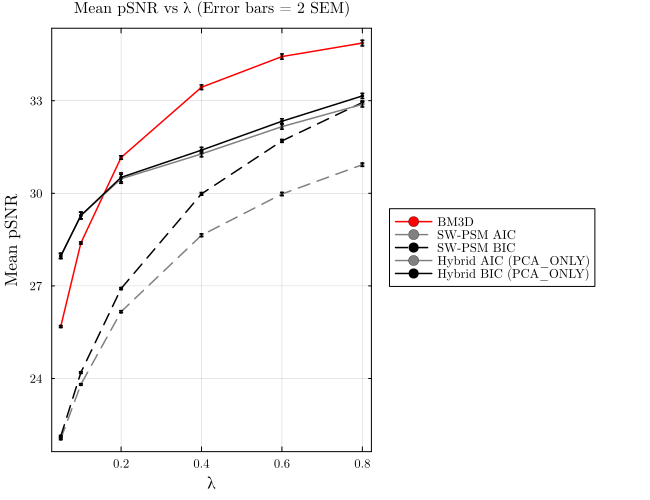

In [55]:
using DataFrames, Statistics, Plots

# -------------------------------
# Aggregate statistics
# -------------------------------
gdf = combine(
    groupby(df, [:lambda, :method]),
    :pSNR => mean => :mean_pSNR,
    :pSNR => std  => :std_pSNR,
    :pSNR => length => :n
)

gdf.sem = gdf.std_pSNR ./ sqrt.(gdf.n)
gdf.err = 2 .* gdf.sem   # 2 standard errors


# ============================================================
# -------- USER CONTROL SECTION ------------------------------
# ============================================================

methods_to_plot = [
   "BM3D",
    "SW-PSM AIC",
    "SW-PSM BIC",
    "Hybrid AIC (PCA_ONLY)",
    "Hybrid BIC (PCA_ONLY)"
]

method_style = Dict(
    "BM3D"                     => (color=:red,    linestyle=:solid),
    "Hybrid AIC (PCA_ONLY)" => (color=:gray,   linestyle=:solid),
    "Hybrid BIC (PCA_ONLY)" => (color=:black,  linestyle=:solid),
    #"PCA_full (no SW-PSM)"     => (color=:orange, linestyle=:dash),
    "SW-PSM AIC"               => (color=:gray,   linestyle=:dash),
    "SW-PSM BIC"               => (color=:black,  linestyle=:dash)
)


# ============================================================
# ----------------------- Plot -------------------------------
# ============================================================

plt = plot(
    size = (650,500),
    legend = :outerright,
    right_margin = 12Plots.mm
)

for method in methods_to_plot
    
    if !(method in gdf.method)
        @warn "Method $method not found in dataframe — skipping."
        continue
    end

    sub = sort(gdf[gdf.method .== method, :], :lambda)
    style = method_style[method]

    plot!(
        plt,
        sub.lambda,
        sub.mean_pSNR,
        yerror = sub.err,
        marker = :circle,
        linewidth = 1.5,
        ms = 2,
        msw=.1,
        linestyle = style.linestyle,
        color = style.color,
        label = method
    )
end

xlabel!("λ")
ylabel!("Mean pSNR")
title!("Mean pSNR vs λ (Error bars = 2 SEM)")

display(plt)
#savefig("meanPSNR_x_lambda_s1")
#CSV.write("SINE_2D_Experiment_S1_WSize8-32.csv", df)

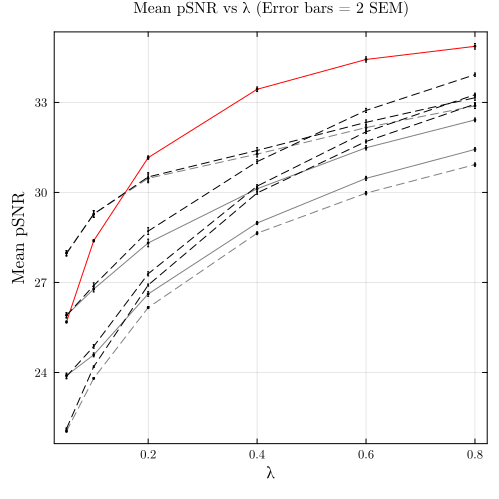

In [38]:
# using Statistics
# using DataFrames
# using Plots

# # -------------------------------
# # Aggregate statistics
# # -------------------------------
# gdf = combine(
#     groupby(df, [:lambda, :method]),
#     :pSNR => mean => :mean_pSNR,
#     :pSNR => std  => :std_pSNR,
#     :pSNR => length => :n
# )

# # gdf = combine(
# #     groupby(df, [:lambda, :method]),
# #     :SNRI => mean => :mean_SNRI,
# #     :SNRI => std  => :std_SNRI,
# #     :SNRI => length => :n
# # )

# gdf.sem = gdf.std_pSNR ./ sqrt.(gdf.n)
# gdf.err = 2 .* gdf.sem   # 2 standard errors

# # -------------------------------
# # Plot
# # -------------------------------
# plt = plot(size=(500,500))
# L_col =:red
# methods_list = sort(unique(gdf.method))   # deterministic order

# for (i, method) in enumerate(methods_list)
#     sub = sort(gdf[gdf.method .== method, :], :lambda)
    
#     ls = i <= 3 ? :solid : :dash

#     if i == 4
#         L_col = :orange
#     end
    
#     if contains(method,"AIC")
#         L_col = :gray
#     end
#     if contains(method,"BIC")
#         L_col = :black
#     end
    
#     plot!(
#         plt,
#         sub.lambda,
#         sub.mean_pSNR,
#         yerror = sub.err,
#         marker = :circle,
#         linewidth = 1,
#         ms=1,
#         linestyle = ls,
#         c=L_col,
#         label = method,
#         legend=false
#     )
# end

# xlabel!("λ")
# ylabel!("Mean pSNR")
# title!("Mean pSNR vs λ (Error bars = 2 SEM)")
# display(plt)


In [15]:
# using CSV
# CSV.write("SINE_2D_Experiment_S1_WSize8-32.csv", df)

In [16]:
enumerate(methods)

enumerate(methods)